In [18]:
# E-commerce Sales & Traffic Analysis — Final Project

### Важливі посилання на матеріали проєкту:
### Інтерактивний Tableau Dashboard (2 сторінки): [Переглянути на Tableau Public](https://public.tableau.com/app/profile/mykyta.yemelianov3525/viz/Book1_17583094938840/UserTrafficDashboard?publish=yes)
### Повний GitHub-репозиторій проєкту:** [Переглянути на GitHub](https://github.com/mykytaggwp/portfolio_da)
### !!! Я не правильно спопачку встановив CSV запит с BigQuerry

In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

sql_query = """
SELECT
    s.date AS session_date,
    s.ga_session_id,
    sp.continent,
    sp.country,
    sp.device AS device_type,
    sp.browser,
    sp.mobile_model_name AS device_model,
    sp.operating_system,
    sp.language AS browser_language,
    sp.medium AS traffic_source,
    sp.channel AS traffic_channel,
    a.id AS user_id,
    a.is_verified AS is_email_confirmed,
    a.is_unsubscribed,
    p.category AS product_category,
    p.name AS product_name,
    p.price,
    p.short_description AS product_description
FROM `data-analytics-mate.DA.session` AS s
LEFT JOIN `data-analytics-mate.DA.session_params` AS sp ON s.ga_session_id = sp.ga_session_id
LEFT JOIN `data-analytics-mate.DA.account_session` AS ans ON s.ga_session_id = ans.ga_session_id
LEFT JOIN `data-analytics-mate.DA.account` AS a ON ans.account_id = a.id
LEFT JOIN `data-analytics-mate.DA.order` AS o ON s.ga_session_id = o.ga_session_id
LEFT JOIN `data-analytics-mate.DA.product` AS p ON o.item_id = p.item_id;
"""

df = pd.read_csv('portfolio_dataset.csv')

In [ ]:
# ==========================================
# 2: Опис отриманого датасету
# ==========================================

In [ ]:
df['session_date'] = pd.to_datetime(df['session_date'])

total_rows, total_cols = df.shape

datetime_cols = df.select_dtypes(include=['datetime64']).columns.tolist()
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category', 'string']).columns.tolist()

unique_sessions = df['ga_session_id'].nunique()
min_date = df['session_date'].min().strftime('%Y-%m-%d')
max_date = df['session_date'].max().strftime('%Y-%m-%d')

null_counts = df.isnull().sum()
null_pct = (null_counts / total_rows) * 100

null_summary = pd.DataFrame({
    'Колонка': null_counts.index,
    'Кількість пропусків': null_counts.values,
    'Відсоток пропусків (%)': null_pct.round(2).values
})
null_summary = null_summary[null_summary['Кількість пропусків'] > 0].reset_index(drop=True)

print(f"--- ЗАГАЛЬНИЙ ОГЛЯД ---")
print(f"Загальна кількість рядків: {total_rows}")
print(f"Загальна кількість колонок: {total_cols}\n")

print(f"--- РОЗПОДІЛ ЗА ТИПАМИ ДАНИХ ---")
print(f"Колонки типу datetime ({len(datetime_cols)}): {datetime_cols}")
print(f"Колонки числового типу ({len(numeric_cols)}): {numeric_cols}")
print(f"Колонки категоріального типу ({len(categorical_cols)}): {categorical_cols}\n")

print(f"--- МЕТРИКИ СЕСІЙ ТА ЧАСУ ---")
print(f"Кількість унікальних сесій: {unique_sessions}")
print(f"Часовий період: від {min_date} до {max_date}\n")

print("--- ПРОПУЩЕНІ ЗНАЧЕННЯ ---")
print(null_summary.to_string(index=False))

--- ЗАГАЛЬНИЙ ОГЛЯД ---
Загальна кількість рядків: 349545
Загальна кількість колонок: 18

--- РОЗПОДІЛ ЗА ТИПАМИ ДАНИХ ---
Колонки типу datetime (1): ['session_date']
Колонки числового типу (5): ['ga_session_id', 'user_id', 'is_email_confirmed', 'is_unsubscribed', 'price']
Колонки категоріального типу (12): ['continent', 'country', 'device_type', 'browser', 'device_model', 'operating_system', 'browser_language', 'traffic_source', 'traffic_channel', 'product_category', 'product_name', 'product_description']

--- МЕТРИКИ СЕСІЙ ТА ЧАСУ ---
Кількість унікальних сесій: 349545
Часовий період: від 2020-11-01 до 2021-01-31

--- ПРОПУЩЕНІ ЗНАЧЕННЯ ---
            Колонка  Кількість пропусків  Відсоток пропусків (%)
   browser_language               114266                   32.69
            user_id               321600                   92.01
 is_email_confirmed               321600                   92.01
    is_unsubscribed               321600                   92.01
   product_category     

In [ ]:
# ==========================================
# КРОК 3.1: Географія продажів (Континенти та Країни)
# ==========================================

In [ ]:
sales_by_continent = df.groupby('continent').agg(
    total_sales=('price', 'sum'),
    orders_count=('price', 'count')
).sort_values(by='total_sales', ascending=False).head(3)

sales_by_country = df.groupby('country').agg(
    total_sales=('price', 'sum'),
    orders_count=('price', 'count')
).sort_values(by='total_sales', ascending=False).head(5)

sales_by_continent['total_sales'] = sales_by_continent['total_sales'].map('{:,.2f} $'.format)
sales_by_country['total_sales'] = sales_by_country['total_sales'].map('{:,.2f} $'.format)

print("--- ТОП-3 КОНТИНЕНТИ ЗА ПРОДАЖАМИ ТА КІЛЬКІСТЮ ЗАМОВЛЕНЬ ---")
print(sales_by_continent.to_string())

print("\n--- ТОП-5 КРАЇН ЗА ПРОДАЖАМИ ТА КІЛЬКІСТЮ ЗАМОВЛЕНЬ ---")
print(sales_by_country.to_string())

--- ТОП-3 КОНТИНЕНТИ ЗА ПРОДАЖАМИ ТА КІЛЬКІСТЮ ЗАМОВЛЕНЬ ---
               total_sales  orders_count
continent                               
Americas   17,665,280.00 $         18553
Asia        7,601,298.30 $          7950
Europe      5,934,624.20 $          6261

--- ТОП-5 КРАЇН ЗА ПРОДАЖАМИ ТА КІЛЬКІСТЮ ЗАМОВЛЕНЬ ---
                    total_sales  orders_count
country                                      
United States   13,943,553.90 $         14673
India            2,809,762.00 $          3029
Canada           2,437,921.00 $          2560
United Kingdom     938,317.90 $          1029
France             710,692.80 $           678


In [ ]:
# ==========================================
# КРОК 3.2: Товарні категорії (Глобально та в країні-лідері)
# ==========================================

In [ ]:
top10_global = df.groupby('product_category')['price'].sum().nlargest(10)

top_country = df.groupby('country')['price'].sum().idxmax()

top10_top_country = df[df['country'] == top_country].groupby('product_category')['price'].sum().nlargest(10)

category_comparison = pd.DataFrame({
    'Глобальні продажі ($)': top10_global.map('{:,.2f}'.format),
    f'Продажі у {top_country} ($)': top10_top_country.map('{:,.2f}'.format)
})

print("--- ТОП-10 КАТЕГОРІЙ ТОВАРІВ: ГЛОБАЛЬНО VS КРАЇНА-ЛІДЕР ---")
print(category_comparison.to_string())

--- ТОП-10 КАТЕГОРІЙ ТОВАРІВ: ГЛОБАЛЬНО VS КРАЇНА-ЛІДЕР ---
                                 Глобальні продажі ($) Продажі у United States ($)
product_category                                                                  
Sofas & armchairs                         8,388,254.50                3,707,144.50
Chairs                                    6,147,748.80                2,619,773.80
Beds                                      4,919,725.00                2,213,058.00
Bookcases & shelving units                3,640,818.10                1,567,606.90
Cabinets & cupboards                      2,336,499.50                  994,545.50
Outdoor furniture                         2,142,222.20                  929,245.20
Tables & desks                            1,790,307.50                  777,865.00
Chests of drawers & drawer units            906,562.50                  382,388.00
Bar furniture                               735,503.00                  330,805.00
Children's furniture       

In [ ]:
# ==========================================
# КРОК 3.3: Аналіз продажів за девайсами та трафіком
# ==========================================

In [ ]:
total_revenue = df['price'].sum()

sales_by_device = (df.groupby('device_type')['price'].sum() / total_revenue * 100).round(2).reset_index()
sales_by_device.columns = ['Тип девайса', 'Частка продажів (%)']
sales_by_device = sales_by_device.sort_values(by='Частка продажів (%)', ascending=False)

sales_by_channel = (df.groupby('traffic_channel')['price'].sum() / total_revenue * 100).round(2).reset_index()
sales_by_channel.columns = ['Канал трафіку', 'Частка продажів (%)']
sales_by_channel = sales_by_channel.sort_values(by='Частка продажів (%)', ascending=False)

sales_by_source = (df.groupby('traffic_source')['price'].sum() / total_revenue * 100).round(2).reset_index()
sales_by_source.columns = ['Джерело трафіку', 'Частка продажів (%)']
sales_by_source = sales_by_source.sort_values(by='Частка продажів (%)', ascending=False).head(5)

print("--- ПРОДАЖІ ЗА ТИПАМИ ДЕВАЙСІВ (%) ---")
print(sales_by_device.to_string(index=False))

print("\n--- ПРОДАЖІ ЗА КАНАЛАМИ ТРАФІКУ (%) ---")
print(sales_by_channel.to_string(index=False))

print("\n--- ТОП-5 ДЖЕРЕЛ ТРАФІКУ ЗА ПРОДАЖАМИ (%) ---")
print(sales_by_source.to_string(index=False))

--- ПРОДАЖІ ЗА ТИПАМИ ДЕВАЙСІВ (%) ---
Тип девайса  Частка продажів (%)
    desktop                59.00
     mobile                38.73
     tablet                 2.26

--- ПРОДАЖІ ЗА КАНАЛАМИ ТРАФІКУ (%) ---
 Канал трафіку  Частка продажів (%)
Organic Search                35.76
   Paid Search                26.62
        Direct                23.44
 Social Search                 7.92
     Undefined                 6.26

--- ТОП-5 ДЖЕРЕЛ ТРАФІКУ ЗА ПРОДАЖАМИ (%) ---
Джерело трафіку  Частка продажів (%)
        organic                34.20
         (none)                23.44
       referral                17.65
        <Other>                14.05
 (data deleted)                 6.39


In [ ]:
# ==========================================
# КРОК 3.4: Аналіз зареєстрованих користувачів та email-розсилки
# ==========================================

In [ ]:
reg_df = df[df['user_id'].notnull()]

unique_users = reg_df.drop_duplicates(subset=['user_id'])
total_unique_users = len(unique_users)

pct_email_confirmed = (unique_users['is_email_confirmed'].mean() * 100).round(2)

pct_unsubscribed = (unique_users['is_unsubscribed'].mean() * 100).round(2)

behavior_comp = reg_df.groupby('is_unsubscribed').agg(
    total_sales=('price', 'sum'),
    orders_count=('price', 'count'),
    avg_order_value=('price', 'mean'),
    unique_users=('user_id', 'nunique')
).reset_index()

behavior_comp['is_unsubscribed'] = behavior_comp['is_unsubscribed'].map({0.0: 'Підписані', 1.0: 'Відписалися'})
behavior_comp['sales_per_user'] = (behavior_comp['total_sales'] / behavior_comp['unique_users']).round(2)

top5_reg_countries = unique_users['country'].value_counts().head(5).reset_index()
top5_reg_countries.columns = ['Країна', 'Кількість користувачів']

print(f"--- ЗАГАЛЬНА СТАТИСТИКА КОРИСТУВАЧІВ ---")
print(f"Усього унікальних зареєстрованих користувачів: {total_unique_users}")
print(f"Частка користувачів з підтвердженим email: {pct_email_confirmed}%")
print(f"Частка користувачів, які відписалися від розсилки: {pct_unsubscribed}%\n")

print("--- ПОРІВНЯННЯ ПОВЕДІНКИ ПІДПИСАНИХ ТА ВІДПИСАНИХ КОРИСТУВАЧІВ ---")
print(behavior_comp.to_string(index=False))

print("\n--- ТОП-5 КРАЇН ЗА КІЛЬКІСТЮ ЗАРЕЄСТРОВАНИХ КОРИСТУВАЧІВ ---")
print(top5_reg_countries.to_string(index=False))

--- ЗАГАЛЬНА СТАТИСТИКА КОРИСТУВАЧІВ ---
Усього унікальних зареєстрованих користувачів: 27945
Частка користувачів з підтвердженим email: 71.7%
Частка користувачів, які відписалися від розсилки: 16.94%

--- ПОРІВНЯННЯ ПОВЕДІНКИ ПІДПИСАНИХ ТА ВІДПИСАНИХ КОРИСТУВАЧІВ ---
is_unsubscribed  total_sales  orders_count  avg_order_value  unique_users  sales_per_user
      Підписані    2150796.9          2334       921.506812         23210           92.67
    Відписалися     431721.6           447       965.820134          4735           91.18

--- ТОП-5 КРАЇН ЗА КІЛЬКІСТЮ ЗАРЕЄСТРОВАНИХ КОРИСТУВАЧІВ ---
        Країна  Кількість користувачів
 United States                   12384
         India                    2687
        Canada                    2067
United Kingdom                     859
        France                     553


In [ ]:
# ==========================================
# КРОК 4.1: Загальна динаміка продажів та сезонність
# ==========================================

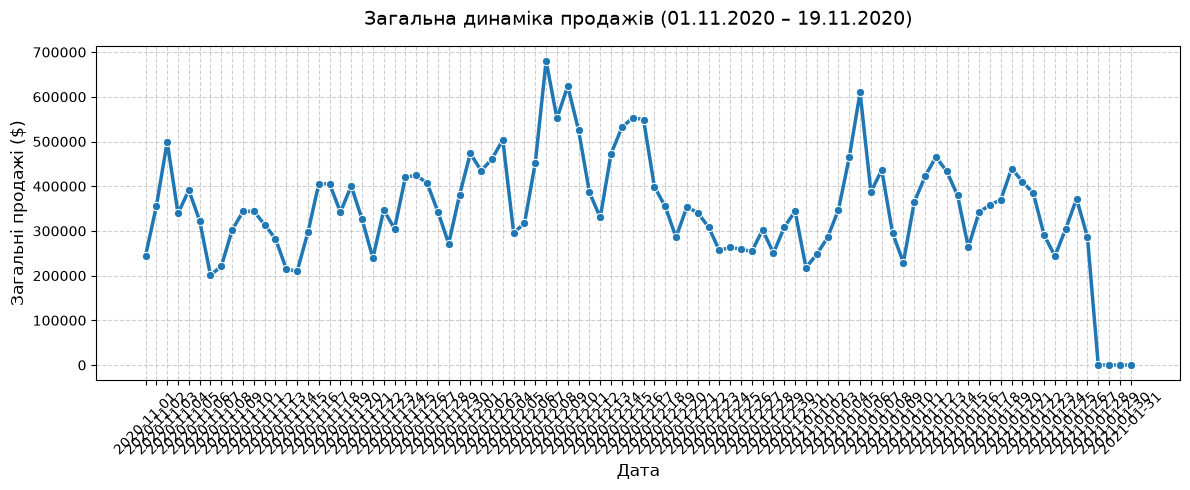

--- ЩОДЕННІ ПРОДАЖІ ТА ДНІ ТИЖНЯ ---
      Дата  Продажі ($) День тижня
2020-11-01 244,292.50 $     Sunday
2020-11-02 355,506.80 $     Monday
2020-11-03 498,979.60 $    Tuesday
2020-11-04 339,187.10 $  Wednesday
2020-11-05 391,276.60 $   Thursday
2020-11-06 322,642.20 $     Friday
2020-11-07 200,892.20 $   Saturday
2020-11-08 221,162.50 $     Sunday
2020-11-09 302,049.50 $     Monday
2020-11-10 343,471.80 $    Tuesday
2020-11-11 343,941.00 $  Wednesday
2020-11-12 314,070.10 $   Thursday
2020-11-13 282,575.40 $     Friday
2020-11-14 214,889.30 $   Saturday
2020-11-15 209,535.50 $     Sunday
2020-11-16 296,972.10 $     Monday
2020-11-17 404,954.60 $    Tuesday
2020-11-18 405,328.10 $  Wednesday
2020-11-19 342,204.40 $   Thursday
2020-11-20 400,420.50 $     Friday
2020-11-21 325,970.70 $   Saturday
2020-11-22 239,063.70 $     Sunday
2020-11-23 346,571.80 $     Monday
2020-11-24 305,073.40 $    Tuesday
2020-11-25 420,232.10 $  Wednesday
2020-11-26 424,028.10 $   Thursday
2020-11-27 407,338

In [ ]:
daily_sales = df.groupby('session_date')['price'].sum().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=daily_sales, x='session_date', y='price', marker='o', color='#1f77b4', linewidth=2.5)

plt.title('Загальна динаміка продажів (01.11.2020 – 19.11.2020)', fontsize=14, pad=15)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Загальні продажі ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(daily_sales['session_date'], rotation=45)
plt.tight_layout()

plt.show()

daily_sales_display = daily_sales.copy()
daily_sales_display['session_date'] = daily_sales_display['session_date'].dt.strftime('%Y-%m-%d')
daily_sales_display['День тижня'] = daily_sales['session_date'].dt.day_name()
daily_sales_display['price'] = daily_sales_display['price'].map('{:,.2f} $'.format)
daily_sales_display.columns = ['Дата', 'Продажі ($)', 'День тижня']

print("--- ЩОДЕННІ ПРОДАЖІ ТА ДНІ ТИЖНЯ ---")
print(daily_sales_display.to_string(index=False))

In [ ]:
# ==========================================
# КРОК 4.2: Динаміка продажів у розрізі континентів
# ==========================================

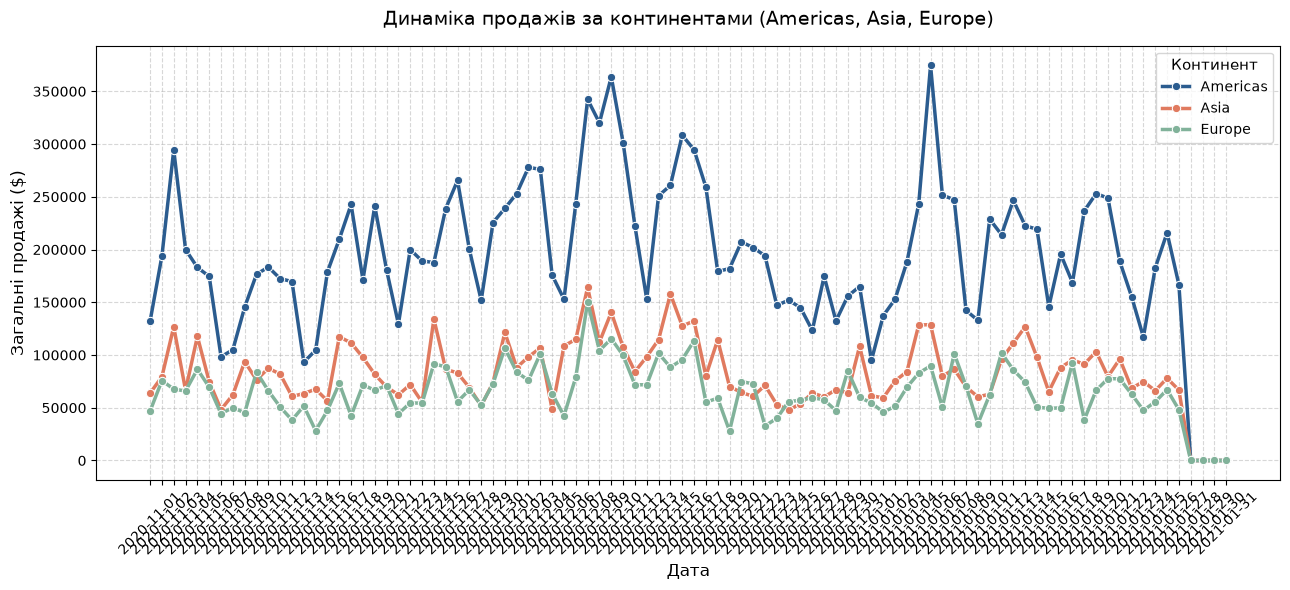

--- ПРОДАЖІ ЗА КОНТИНЕНТАМИ ПО ДНЯХ ---
continent         Americas          Asia       Europe
session_date                                         
2020-11-01    132,002.50 $   63,823.00 $  46,908.00 $
2020-11-02    193,861.00 $   79,370.00 $  75,710.80 $
2020-11-03    294,529.80 $  126,737.80 $  67,692.00 $
2020-11-04    200,009.50 $   66,602.00 $  65,915.00 $
2020-11-05    182,988.20 $  117,608.40 $  86,540.00 $
...                    ...           ...          ...
2021-01-27    166,735.50 $   66,783.10 $  48,156.10 $
2021-01-28          0.00 $        0.00 $       0.00 $
2021-01-29          0.00 $        0.00 $       0.00 $
2021-01-30          0.00 $        0.00 $       0.00 $
2021-01-31          0.00 $        0.00 $       0.00 $

[92 rows x 3 columns]


In [ ]:
top_continents = ['Americas', 'Asia', 'Europe']
df_continents = df[df['continent'].isin(top_continents)]

continent_daily = df_continents.groupby(['session_date', 'continent'])['price'].sum().reset_index()

plt.figure(figsize=(13, 6))
palette = {'Americas': '#2b5c8f', 'Asia': '#e07a5f', 'Europe': '#81b29a'}

sns.lineplot(
    data=continent_daily,
    x='session_date',
    y='price',
    hue='continent',
    palette=palette,
    linewidth=2.5,
    marker='o'
)

plt.title('Динаміка продажів за континентами (Americas, Asia, Europe)', fontsize=14, pad=15)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Загальні продажі ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Континент', title_fontsize='11', fontsize='10')
plt.xticks(daily_sales['session_date'], rotation=45)
plt.tight_layout()

# Відображення графіка
plt.show()

# Звідна таблиця для аналізу даних
pivot_continents = continent_daily.pivot(index='session_date', columns='continent', values='price').fillna(0)
pivot_continents.index = pivot_continents.index.strftime('%Y-%m-%d')

# Універсальне форматування для будь-якої версії Pandas
pivot_continents_formatted = pivot_continents.apply(lambda col: col.map('{:,.2f} $'.format))

print("--- ПРОДАЖІ ЗА КОНТИНЕНТАМИ ПО ДНЯХ ---")
print(pivot_continents_formatted)

In [ ]:
# ==========================================
# КРОК 4.3: Динаміка продажів у розрізі каналів трафіку
# ==========================================

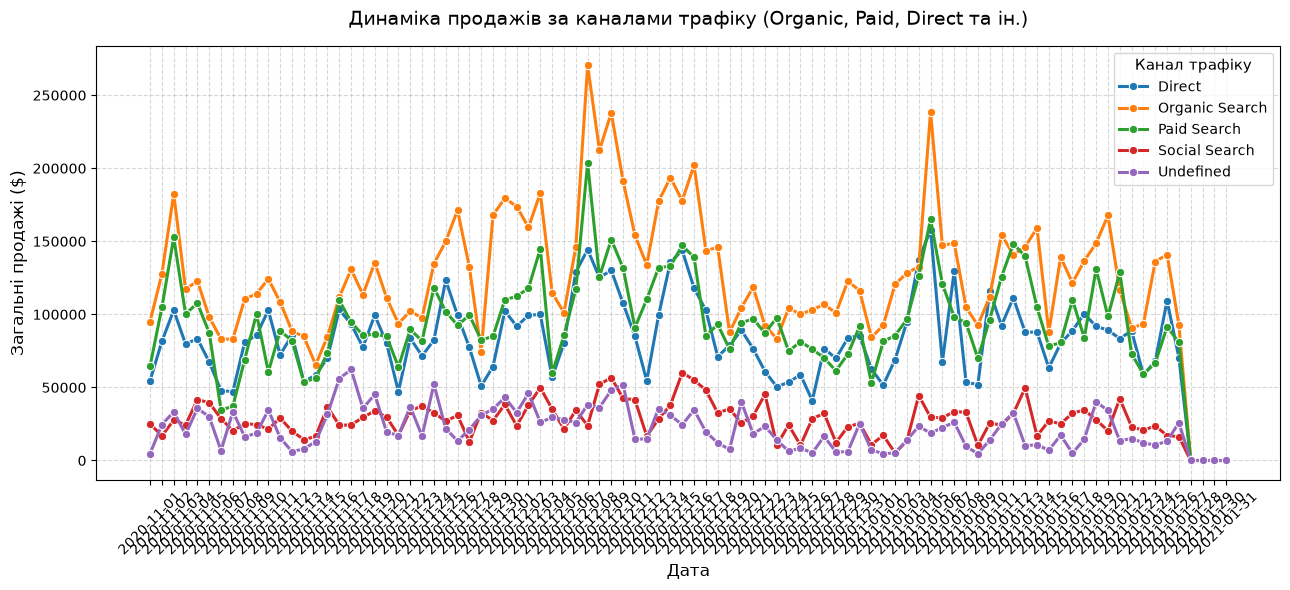

--- ПРОДАЖІ ЗА КАНАЛАМИ ТРАФІКУ ПО ДНЯХ ---
traffic_channel        Direct Organic Search   Paid Search Social Search  \
session_date                                                               
2020-11-01        54,669.50 $    95,112.00 $   64,688.00 $   25,078.00 $   
2020-11-02        81,561.50 $   127,746.50 $  104,780.80 $   16,843.00 $   
2020-11-03       102,909.50 $   182,521.90 $  152,641.30 $   27,652.50 $   
2020-11-04        79,683.60 $   117,067.10 $  100,332.00 $   24,257.40 $   
2020-11-05        83,367.60 $   122,938.40 $  107,648.00 $   41,693.20 $   
...                       ...            ...           ...           ...   
2021-01-27        70,423.10 $    92,921.10 $   80,869.50 $   16,282.00 $   
2021-01-28             0.00 $         0.00 $        0.00 $        0.00 $   
2021-01-29             0.00 $         0.00 $        0.00 $        0.00 $   
2021-01-30             0.00 $         0.00 $        0.00 $        0.00 $   
2021-01-31             0.00 $         0.00 $

In [ ]:
channel_daily = df.groupby(['session_date', 'traffic_channel'])['price'].sum().reset_index()

plt.figure(figsize=(13, 6))

sns.lineplot(
    data=channel_daily,
    x='session_date',
    y='price',
    hue='traffic_channel',
    linewidth=2.2,
    marker='o'
)

plt.title('Динаміка продажів за каналами трафіку (Organic, Paid, Direct та ін.)', fontsize=14, pad=15)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Загальні продажі ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Канал трафіку', title_fontsize='11', fontsize='10')
plt.xticks(daily_sales['session_date'], rotation=45)
plt.tight_layout()

plt.show()

pivot_channels = channel_daily.pivot(index='session_date', columns='traffic_channel', values='price').fillna(0)
pivot_channels.index = pivot_channels.index.strftime('%Y-%m-%d')
pivot_channels_formatted = pivot_channels.apply(lambda col: col.map('{:,.2f} $'.format))

print("--- ПРОДАЖІ ЗА КАНАЛАМИ ТРАФІКУ ПО ДНЯХ ---")
print(pivot_channels_formatted)

In [ ]:
# ==========================================
# КРОК 4.4: Динаміка продажів у розрізі типів девайсів
# ==========================================

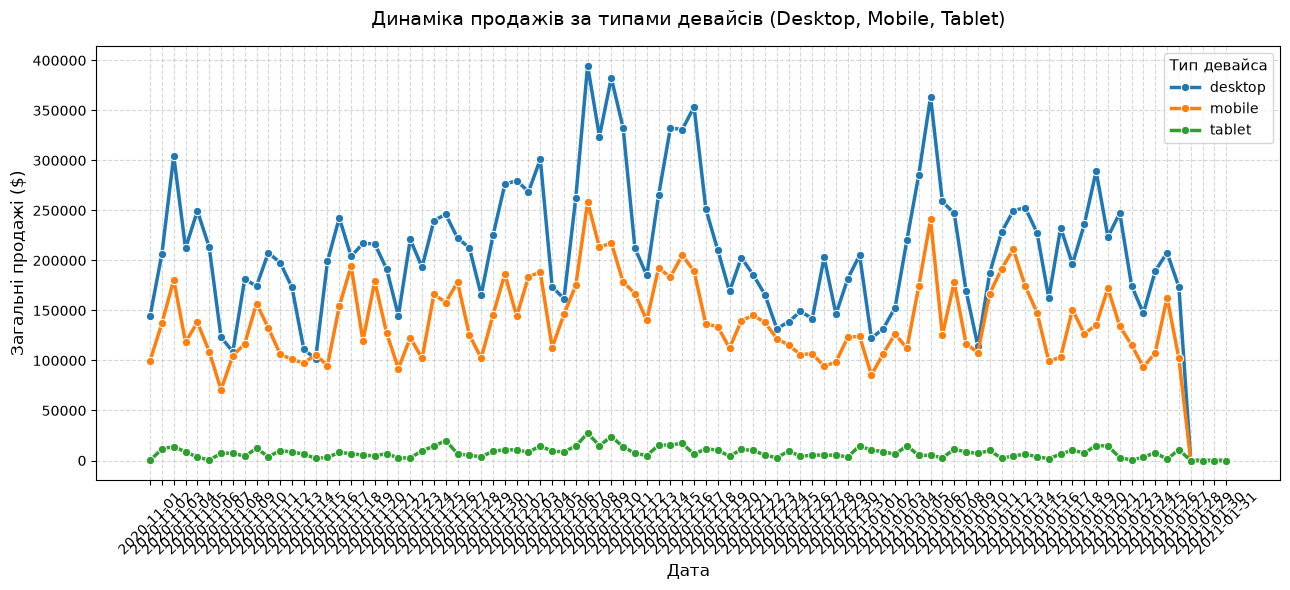

--- ПРОДАЖІ ЗА ТИПАМИ ДЕВАЙСІВ ПО ДНЯХ ---
device_type        desktop        mobile       tablet
session_date                                         
2020-11-01    144,445.00 $   99,698.50 $     149.00 $
2020-11-02    206,727.30 $  137,269.50 $  11,510.00 $
2020-11-03    304,473.80 $  180,602.80 $  13,903.00 $
2020-11-04    212,227.70 $  118,324.40 $   8,635.00 $
2020-11-05    249,682.00 $  138,256.00 $   3,338.60 $
...                    ...           ...          ...
2021-01-27    173,453.50 $  102,042.20 $  10,845.00 $
2021-01-28          0.00 $        0.00 $       0.00 $
2021-01-29          0.00 $        0.00 $       0.00 $
2021-01-30          0.00 $        0.00 $       0.00 $
2021-01-31          0.00 $        0.00 $       0.00 $

[92 rows x 3 columns]


In [ ]:
device_daily = df.groupby(['session_date', 'device_type'])['price'].sum().reset_index()

plt.figure(figsize=(13, 6))
palette_device = {'desktop': '#1f77b4', 'mobile': '#ff7f0e', 'tablet': '#2ca02c'}

sns.lineplot(
    data=device_daily,
    x='session_date',
    y='price',
    hue='device_type',
    palette=palette_device,
    linewidth=2.5,
    marker='o'
)

plt.title('Динаміка продажів за типами девайсів (Desktop, Mobile, Tablet)', fontsize=14, pad=15)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Загальні продажі ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Тип девайса', title_fontsize='11', fontsize='10')
plt.xticks(daily_sales['session_date'], rotation=45)
plt.tight_layout()

plt.show()

pivot_devices = device_daily.pivot(index='session_date', columns='device_type', values='price').fillna(0)
pivot_devices.index = pivot_devices.index.strftime('%Y-%m-%d')
pivot_devices_formatted = pivot_devices.apply(lambda col: col.map('{:,.2f} $'.format))

print("--- ПРОДАЖІ ЗА ТИПАМИ ДЕВАЙСІВ ПО ДНЯХ ---")
print(pivot_devices_formatted)

In [ ]:
# ==========================================
# КРОК 5.1: Зведена таблиця: Сесії за каналами трафіку та девайсами
# ==========================================

In [ ]:
df_filtered_sessions = df[
    (df['traffic_channel'].notnull()) &
    (df['traffic_channel'] != 'Undefined') &
    (df['device_type'].notnull()) &
    (df['device_type'] != 'Undefined')
]

pivot_sessions = pd.pivot_table(
    df_filtered_sessions,
    index='traffic_channel',
    columns='device_type',
    values='ga_session_id',
    aggfunc='nunique',
    margins=True,
    margins_name='Всього'
)

pivot_sessions_formatted = pivot_sessions.apply(lambda col: col.map('{:,.0f}'.format))

print("--- ЗВЕДЕНА ТАБЛИЦЯ: КІЛЬКІСТЬ СЕСІЙ ЗА КАНАЛАМИ ТРАФІКУ ТА ДЕВАЙСАМИ ---")
print(pivot_sessions_formatted)

--- ЗВЕДЕНА ТАБЛИЦЯ: КІЛЬКІСТЬ СЕСІЙ ЗА КАНАЛАМИ ТРАФІКУ ТА ДЕВАЙСАМИ ---
device_type      desktop   mobile tablet   Всього
traffic_channel                                  
Direct            47,825   31,745  1,812   81,382
Organic Search    72,622   49,014  2,789  124,425
Paid Search       55,167   37,034  2,140   94,341
Social Search     16,288   10,988    638   27,914
Всього           191,902  128,781  7,379  328,062


In [ ]:
# ==========================================
# КРОК 5.2: Зведена таблиця: Продажі Топ-10 категорій у Топ-5 країнах
# ==========================================

In [ ]:
top5_countries = df.groupby('country')['price'].sum().nlargest(5).index.tolist()
top10_categories = df.groupby('product_category')['price'].sum().nlargest(10).index.tolist()

df_top_sales = df[df['country'].isin(top5_countries) & df['product_category'].isin(top10_categories)]

pivot_sales = pd.pivot_table(
    df_top_sales,
    index='product_category',
    columns='country',
    values='price',
    aggfunc='sum',
    fill_value=0,
    margins=True,
    margins_name='Всього'
).sort_values(by='Всього', ascending=False)

country_cols = [c for c in top5_countries if c in pivot_sales.columns] + ['Всього']
pivot_sales = pivot_sales[country_cols]

pivot_sales_formatted = pivot_sales.apply(lambda col: col.map('{:,.2f} $'.format))

print("--- ЗВЕДЕНА ТАБЛИЦЯ: ПРОДАЖІ ТОП-10 КАТЕГОРІЙ У ТОП-5 КРАЇНАХ ---")
print(pivot_sales_formatted)

--- ЗВЕДЕНА ТАБЛИЦЯ: ПРОДАЖІ ТОП-10 КАТЕГОРІЙ У ТОП-5 КРАЇНАХ ---
country                             United States           India  \
product_category                                                    
Всього                            13,730,006.90 $  2,765,846.00 $   
Sofas & armchairs                  3,707,144.50 $    788,430.00 $   
Chairs                             2,619,773.80 $    544,309.20 $   
Beds                               2,213,058.00 $    358,319.50 $   
Bookcases & shelving units         1,567,606.90 $    364,507.40 $   
Cabinets & cupboards                 994,545.50 $    191,888.00 $   
Outdoor furniture                    929,245.20 $    162,289.40 $   
Tables & desks                       777,865.00 $    186,157.50 $   
Chests of drawers & drawer units     382,388.00 $     73,111.00 $   
Bar furniture                        330,805.00 $     57,657.00 $   
Children's furniture                 207,575.00 $     39,177.00 $   

country                             

In [ ]:
# ==========================================
# КРОК 5.3: Власні додаткові зведені таблиці
# ==========================================

In [ ]:
# ------------------------------------------
# 1. Зведена таблиця: Середній чек за континентами та девайсами
# ------------------------------------------
pivot_avg_check = pd.pivot_table(
    df[df['price'].notnull()],
    index='continent',
    columns='device_type',
    values='price',
    aggfunc='mean'
).dropna(how='all')

pivot_avg_check_formatted = pivot_avg_check.apply(lambda col: col.map('{:,.2f} $'.format))

print("--- ВЛАСНА ЗВЕДЕНА ТАБЛИЦЯ 1: СЕРЕДНІЙ ЧЕК ЗА КОНТИНЕНТАМИ ТА ДЕВАЙСАМИ ---")
print(pivot_avg_check_formatted)


# ------------------------------------------
# 2. Зведена таблиця: Конверсія сесій у покупки (%) за каналами трафіку та континентами
# ------------------------------------------
pivot_conversion = pd.pivot_table(
    df,
    index='traffic_channel',
    columns='continent',
    values='price',
    aggfunc=lambda x: (x.notnull().sum() / len(x)) * 100
)

main_continents = ['Americas', 'Asia', 'Europe', 'Africa', 'Oceania']
pivot_conversion = pivot_conversion[[c for c in main_continents if c in pivot_conversion.columns]]

pivot_conversion_formatted = pivot_conversion.apply(lambda col: col.map('{:.2f} %'.format))

print("\n--- ВЛАСНА ЗВЕДЕНА ТАБЛИЦЯ 2: КОНВЕРСІЯ СЕСІЙ У ПОКУПКИ (%) ---")
print(pivot_conversion_formatted)

--- ВЛАСНА ЗВЕДЕНА ТАБЛИЦЯ 1: СЕРЕДНІЙ ЧЕК ЗА КОНТИНЕНТАМИ ТА ДЕВАЙСАМИ ---
device_type     desktop      mobile      tablet
continent                                      
(not set)    1,032.87 $  1,117.70 $     70.00 $
Africa       1,030.02 $    907.48 $    987.14 $
Americas       962.17 $    936.26 $    966.60 $
Asia           940.15 $    971.46 $  1,110.69 $
Europe         955.43 $    935.09 $    978.02 $
Oceania      1,039.48 $    942.73 $    847.78 $

--- ВЛАСНА ЗВЕДЕНА ТАБЛИЦЯ 2: КОНВЕРСІЯ СЕСІЙ У ПОКУПКИ (%) ---
continent       Americas    Asia  Europe   Africa  Oceania
traffic_channel                                           
Direct            9.58 %  9.50 %  9.82 %   8.34 %   9.09 %
Organic Search    9.52 %  9.66 %  9.65 %  10.54 %   9.64 %
Paid Search       9.62 %  9.55 %  9.51 %   8.74 %  10.29 %
Social Search     9.88 %  9.15 %  9.89 %  10.92 %   9.78 %
Undefined         9.77 %  9.85 %  8.70 %   7.63 %  11.56 %


In [ ]:
# ==========================================
# КРОК 6.1: Кореляція між кількістю сесій та продажами по днях
# ==========================================

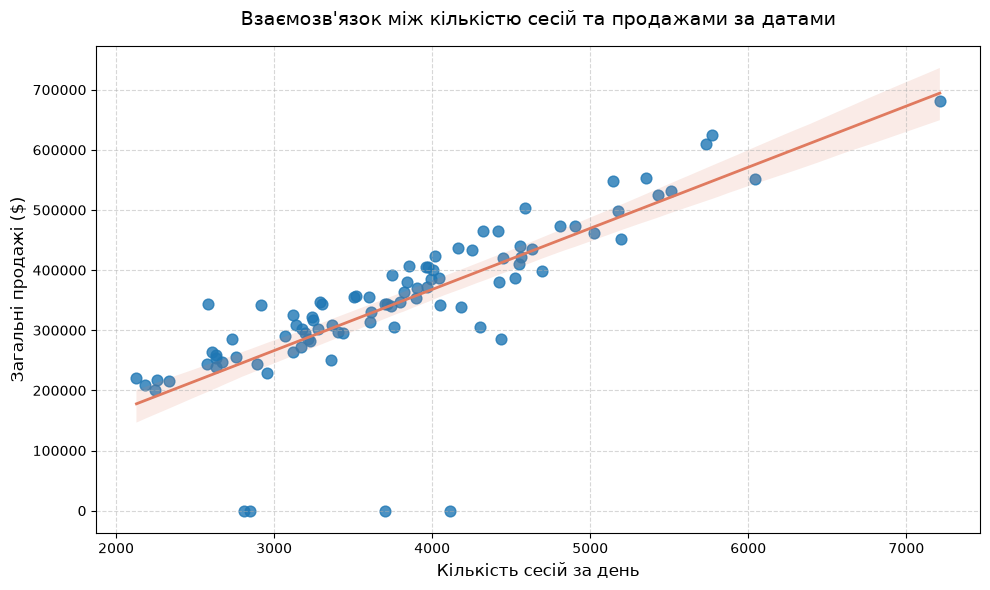

--- СТАТИСТИЧНИЙ АНАЛІЗ ЗВ'ЯЗКУ ---
Коефіцієнт кореляції Пірсона (r): 0.7911
p-value (Пірсон): 6.4835e-21
Коефіцієнт кореляції Спірмена (rho): 0.8653
p-value (Спірмен): 9.7559e-29


In [ ]:
daily_metrics = df.groupby('session_date').agg(
    total_sessions=('ga_session_id', 'nunique'),
    total_sales=('price', 'sum')
).reset_index()

r_pearson, p_pearson = stats.pearsonr(daily_metrics['total_sessions'], daily_metrics['total_sales'])
r_spearman, p_spearman = stats.spearmanr(daily_metrics['total_sessions'], daily_metrics['total_sales'])

plt.figure(figsize=(10, 6))
sns.regplot(
    data=daily_metrics,
    x='total_sessions',
    y='total_sales',
    color='#1f77b4',
    scatter_kws={'s': 60, 'alpha': 0.8},
    line_kws={'color': '#e07a5f', 'linewidth': 2}
)

plt.title('Взаємозв\'язок між кількістю сесій та продажами за датами', fontsize=14, pad=15)
plt.xlabel('Кількість сесій за день', fontsize=12)
plt.ylabel('Загальні продажі ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

print("--- СТАТИСТИЧНИЙ АНАЛІЗ ЗВ'ЯЗКУ ---")
print(f"Коефіцієнт кореляції Пірсона (r): {r_pearson:.4f}")
print(f"p-value (Пірсон): {p_pearson:.4e}")
print(f"Коефіцієнт кореляції Спірмена (rho): {r_spearman:.4f}")
print(f"p-value (Спірмен): {p_spearman:.4e}")

In [ ]:
# ==========================================
# КРОК 6.2: Кореляція продажів між Топ-3 континентами
# ==========================================

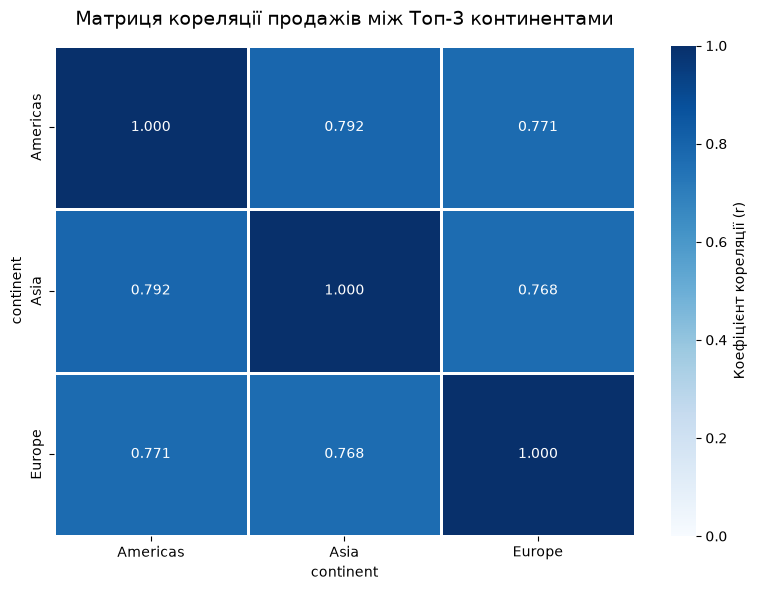

--- МАТРИЦЯ КОРЕЛЯЦІЇ (r) ---
continent  Americas    Asia  Europe
continent                          
Americas     1.0000  0.7920  0.7706
Asia         0.7920  1.0000  0.7684
Europe       0.7706  0.7684  1.0000

--- МАТРИЦЯ P-VALUE ---
continent Americas    Asia  Europe
continent                         
Americas    0.0000  0.0000  0.0000
Asia        0.0000  0.0000  0.0000
Europe      0.0000  0.0000  0.0000


In [ ]:
top3_continents = ['Americas', 'Asia', 'Europe']
daily_continents_sales = df[df['continent'].isin(top3_continents)].pivot_table(
    index='session_date',
    columns='continent',
    values='price',
    aggfunc='sum'
).fillna(0)

corr_cont = daily_continents_sales.corr(method='pearson')

p_values_cont = pd.DataFrame(index=corr_cont.index, columns=corr_cont.columns)
for col1 in daily_continents_sales.columns:
    for col2 in daily_continents_sales.columns:
        _, p_val = stats.pearsonr(daily_continents_sales[col1], daily_continents_sales[col2])
        p_values_cont.loc[col1, col2] = p_val

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_cont,
    annot=True,
    fmt=".3f",
    cmap='Blues',
    vmin=0,
    vmax=1,
    linewidths=1,
    cbar_kws={'label': 'Коефіцієнт кореляції (r)'}
)

plt.title('Матриця кореляції продажів між Топ-3 континентами', fontsize=14, pad=15)
plt.tight_layout()

plt.show()

print("--- МАТРИЦЯ КОРЕЛЯЦІЇ (r) ---")
print(corr_cont.round(4))

print("\n--- МАТРИЦЯ P-VALUE ---")
print(p_values_cont.apply(lambda col: col.map('{:.4f}'.format)))

In [ ]:
# ==========================================
# КРОК 6.3: Кореляція продажів між каналами трафіку
# ==========================================

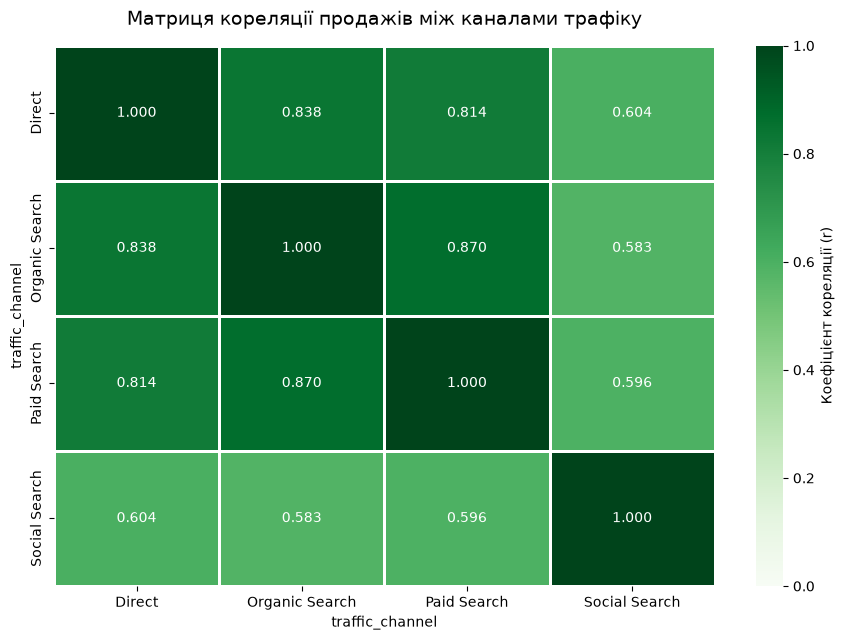

--- МАТРИЦЯ КОРЕЛЯЦІЇ (r) ---
traffic_channel  Direct  Organic Search  Paid Search  Social Search
traffic_channel                                                    
Direct           1.0000          0.8378       0.8141         0.6041
Organic Search   0.8378          1.0000       0.8701         0.5831
Paid Search      0.8141          0.8701       1.0000         0.5964
Social Search    0.6041          0.5831       0.5964         1.0000

--- МАТРИЦЯ P-VALUE ---
traffic_channel    Direct Organic Search Paid Search Social Search
traffic_channel                                                   
Direct           0.000000       0.000000    0.000000      0.000000
Organic Search   0.000000       0.000000    0.000000      0.000000
Paid Search      0.000000       0.000000    0.000000      0.000000
Social Search    0.000000       0.000000    0.000000      0.000000


In [ ]:
main_channels = ['Organic Search', 'Paid Search', 'Direct', 'Social Search']
daily_channels_sales = df[df['traffic_channel'].isin(main_channels)].pivot_table(
    index='session_date',
    columns='traffic_channel',
    values='price',
    aggfunc='sum'
).fillna(0)

corr_chan = daily_channels_sales.corr(method='pearson')

p_values_chan = pd.DataFrame(index=corr_chan.index, columns=corr_chan.columns)
for col1 in daily_channels_sales.columns:
    for col2 in daily_channels_sales.columns:
        _, p_val = stats.pearsonr(daily_channels_sales[col1], daily_channels_sales[col2])
        p_values_chan.loc[col1, col2] = p_val

plt.figure(figsize=(9, 6.5))
sns.heatmap(
    corr_chan,
    annot=True,
    fmt=".3f",
    cmap='Greens',
    vmin=0,
    vmax=1,
    linewidths=1,
    cbar_kws={'label': 'Коефіцієнт кореляції (r)'}
)

plt.title('Матриця кореляції продажів між каналами трафіку', fontsize=14, pad=15)
plt.tight_layout()

plt.show()

print("--- МАТРИЦЯ КОРЕЛЯЦІЇ (r) ---")
print(corr_chan.round(4))

print("\n--- МАТРИЦЯ P-VALUE ---")
print(p_values_chan.apply(lambda col: col.map('{:.6f}'.format)))

In [ ]:
# ==========================================
# КРОК 6.4: Кореляція продажів між Топ-5 категоріями товарів
# ==========================================

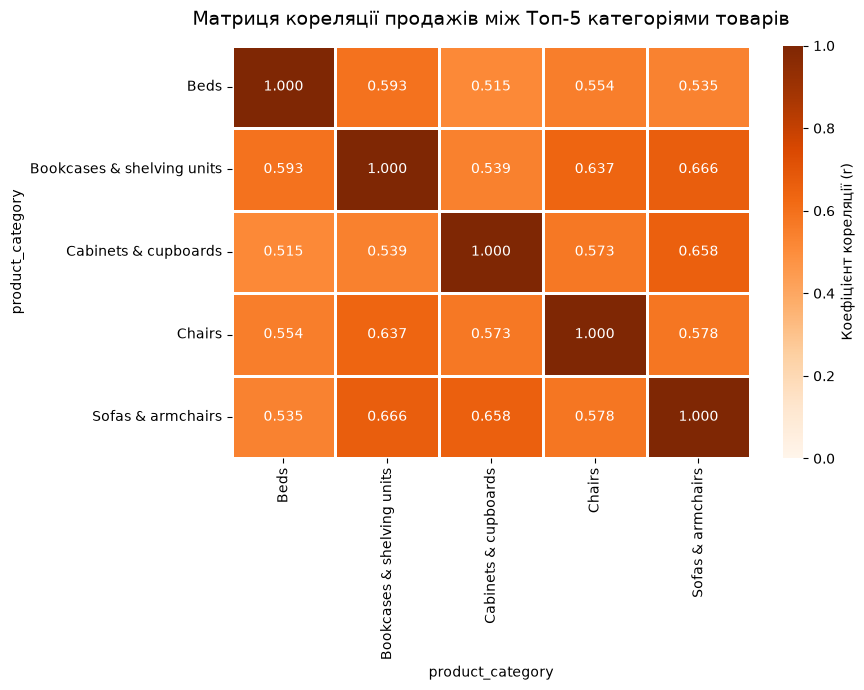

--- МАТРИЦЯ КОРЕЛЯЦІЇ (r) ---
product_category              Beds  Bookcases & shelving units  \
product_category                                                 
Beds                        1.0000                      0.5929   
Bookcases & shelving units  0.5929                      1.0000   
Cabinets & cupboards        0.5146                      0.5394   
Chairs                      0.5545                      0.6371   
Sofas & armchairs           0.5354                      0.6662   

product_category            Cabinets & cupboards  Chairs  Sofas & armchairs  
product_category                                                             
Beds                                      0.5146  0.5545             0.5354  
Bookcases & shelving units                0.5394  0.6371             0.6662  
Cabinets & cupboards                      1.0000  0.5729             0.6576  
Chairs                                    0.5729  1.0000             0.5782  
Sofas & armchairs                      

In [ ]:
top5_cats = df.groupby('product_category')['price'].sum().nlargest(5).index.tolist()

daily_cats_sales = df[df['product_category'].isin(top5_cats)].pivot_table(
    index='session_date',
    columns='product_category',
    values='price',
    aggfunc='sum'
).fillna(0)

corr_cats = daily_cats_sales.corr(method='pearson')

p_values_cats = pd.DataFrame(index=corr_cats.index, columns=corr_cats.columns)
for col1 in daily_cats_sales.columns:
    for col2 in daily_cats_sales.columns:
        _, p_val = stats.pearsonr(daily_cats_sales[col1], daily_cats_sales[col2])
        p_values_cats.loc[col1, col2] = p_val

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_cats,
    annot=True,
    fmt=".3f",
    cmap='Oranges',
    vmin=0,
    vmax=1,
    linewidths=1,
    cbar_kws={'label': 'Коефіцієнт кореляції (r)'}
)

plt.title('Матриця кореляції продажів між Топ-5 категоріями товарів', fontsize=14, pad=15)
plt.tight_layout()

plt.show()

print("--- МАТРИЦЯ КОРЕЛЯЦІЇ (r) ---")
print(corr_cats.round(4))

print("\n--- МАТРИЦЯ P-VALUE ---")
print(p_values_cats.apply(lambda col: col.map('{:.6f}'.format)))

In [ ]:
# ==========================================
# КРОК 6.5: Додатковий аналіз взаємозв'язків (Desktop vs Mobile та Замовлення vs AOV)
# ==========================================

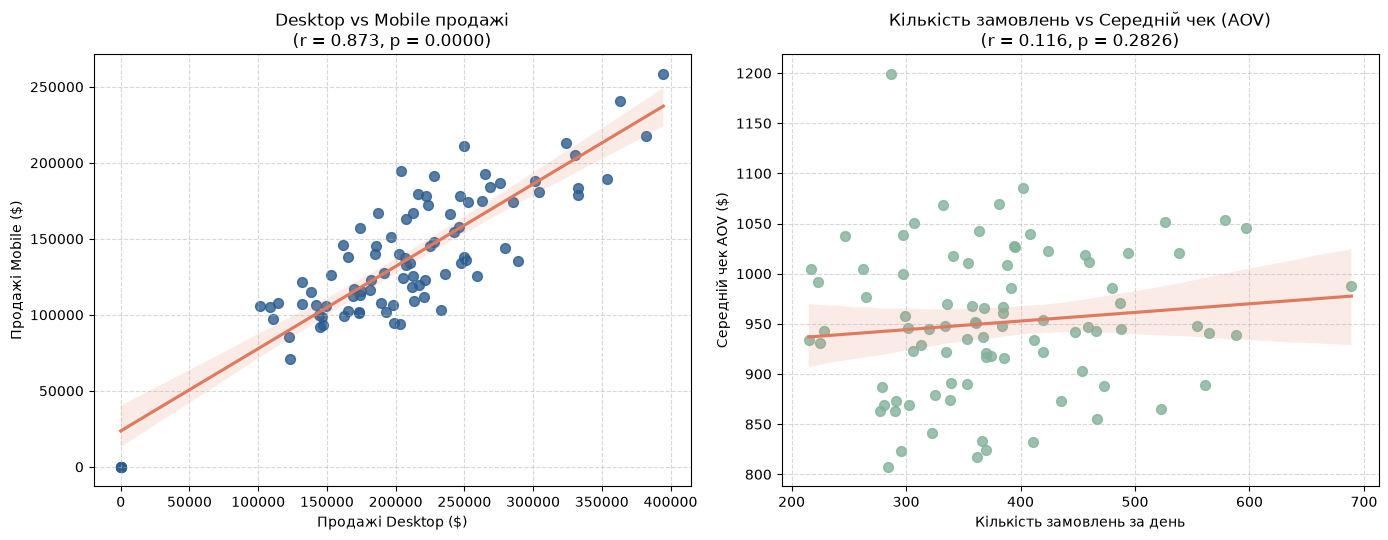

--- СТАТИСТИКА ДОДАТКОВИХ ВЗАЄМОЗВ'ЯЗКІВ ---
1. Desktop vs Mobile: r = 0.8732, p-value = 0.000000 (Статистично значуще)
2. Замовлення vs AOV: r = 0.1158, p-value = 0.2826 (НЕ значуще)


In [ ]:
daily_devices = df.pivot_table(
    index='session_date',
    columns='device_type',
    values='price',
    aggfunc='sum'
).fillna(0)

r_dev, p_dev = stats.pearsonr(daily_devices['desktop'], daily_devices['mobile'])

# 2. Формуємо дані для перевірки залежності між кількістю замовлень та середнім чеком (AOV)
daily_aov = df[df['price'].notnull()].groupby('session_date').agg(
    orders_count=('price', 'count'),
    aov=('price', 'mean')
).reset_index()

r_aov, p_aov = stats.pearsonr(daily_aov['orders_count'], daily_aov['aov'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sns.regplot(
    data=daily_devices,
    x='desktop',
    y='mobile',
    ax=axes[0],
    color='#2b5c8f',
    scatter_kws={'s': 50},
    line_kws={'color': '#e07a5f'}
)
axes[0].set_title(f'Desktop vs Mobile продажі\n(r = {r_dev:.3f}, p = {p_dev:.4f})', fontsize=12)
axes[0].set_xlabel('Продажі Desktop ($)')
axes[0].set_ylabel('Продажі Mobile ($)')
axes[0].grid(True, linestyle='--', alpha=0.5)

sns.regplot(
    data=daily_aov,
    x='orders_count',
    y='aov',
    ax=axes[1],
    color='#81b29a',
    scatter_kws={'s': 50},
    line_kws={'color': '#e07a5f'}
)
axes[1].set_title(f'Кількість замовлень vs Середній чек (AOV)\n(r = {r_aov:.3f}, p = {p_aov:.4f})', fontsize=12)
axes[1].set_xlabel('Кількість замовлень за день')
axes[1].set_ylabel('Середній чек AOV ($)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("--- СТАТИСТИКА ДОДАТКОВИХ ВЗАЄМОЗВ'ЯЗКІВ ---")
print(f"1. Desktop vs Mobile: r = {r_dev:.4f}, p-value = {p_dev:.6f} (Статистично значуще)")
print(f"2. Замовлення vs AOV: r = {r_aov:.4f}, p-value = {p_aov:.4f} (НЕ значуще)")


In [ ]:
# ==========================================
# КРОК 7.1: Статистичний аналіз: Зареєстровані vs Незареєстровані користувачі
# ==========================================

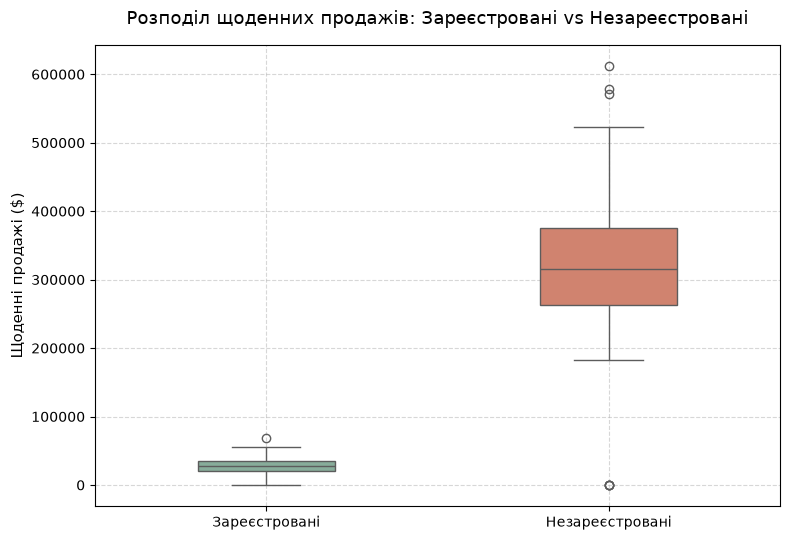

--- СЕРЕДНІ ЗНАЧЕННЯ ---
Середні щоденні продажі (Зареєстровані): 28,070.85 $
Середні щоденні продажі (Незареєстровані): 319,447.96 $

--- ТЕСТ НА НОРМАЛЬНІСТЬ (Шапіро-Уїлк) ---
Зареєстровані: p-value = 0.1482
Незареєстровані: p-value = 0.0012

--- КРИТЕРІЙ МАННА-УЇТНІ ---
U-статистика: 360.0
p-value: 8.3795e-27


In [ ]:
reg_sales_daily = df[df['user_id'].notnull()].groupby('session_date')['price'].sum()
non_reg_sales_daily = df[df['user_id'].isnull()].groupby('session_date')['price'].sum()

daily_users_df = pd.DataFrame({
    'Зареєстровані': reg_sales_daily,
    'Незареєстровані': non_reg_sales_daily
}).fillna(0)

stat_reg, p_norm_reg = stats.shapiro(daily_users_df['Зареєстровані'])
stat_non_reg, p_norm_non_reg = stats.shapiro(daily_users_df['Незареєстровані'])

mwu_stat, p_value_mwu = stats.mannwhitneyu(
    daily_users_df['Зареєстровані'],
    daily_users_df['Незареєстровані'],
    alternative='two-sided'
)

plt.figure(figsize=(8, 5.5))
sns.boxplot(data=daily_users_df, palette=['#81b29a', '#e07a5f'], width=0.4)

plt.title('Розподіл щоденних продажів: Зареєстровані vs Незареєстровані', fontsize=13, pad=15)
plt.ylabel('Щоденні продажі ($)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("--- СЕРЕДНІ ЗНАЧЕННЯ ---")
print(f"Середні щоденні продажі (Зареєстровані): {daily_users_df['Зареєстровані'].mean():,.2f} $")
print(f"Середні щоденні продажі (Незареєстровані): {daily_users_df['Незареєстровані'].mean():,.2f} $\n")

print("--- ТЕСТ НА НОРМАЛЬНІСТЬ (Шапіро-Уїлк) ---")
print(f"Зареєстровані: p-value = {p_norm_reg:.4f}")
print(f"Незареєстровані: p-value = {p_norm_non_reg:.4f}\n")

print("--- КРИТЕРІЙ МАННА-УЇТНІ ---")
print(f"U-статистика: {mwu_stat}")
print(f"p-value: {p_value_mwu:.4e}")

In [ ]:
# ==========================================
# КРОК 7.2: Статистичний аналіз: Кількість сесій за каналами трафіку
# ==========================================

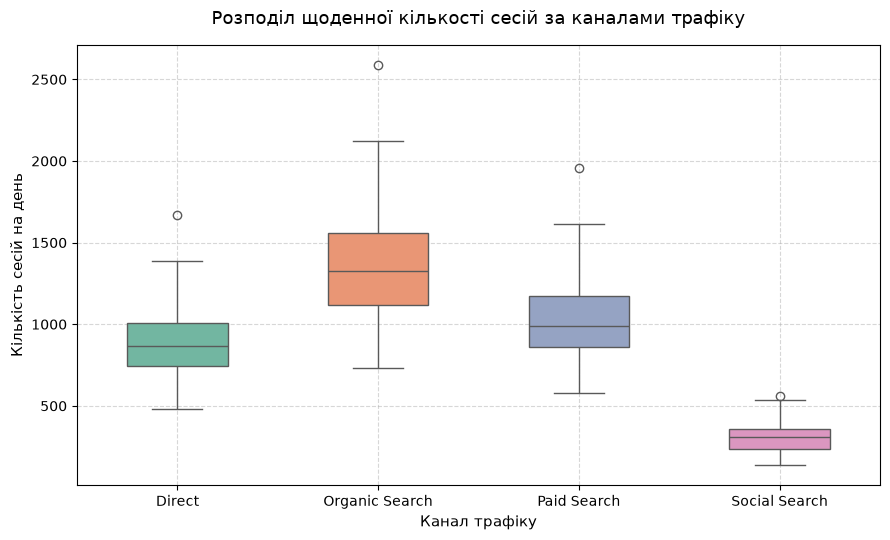

--- СЕРЕДНЯ ЩОДЕННА КІЛЬКІСТЬ СЕСІЙ ---
traffic_channel
Direct             884.59
Organic Search    1352.45
Paid Search       1025.45
Social Search      303.41

--- ТЕСТ КРАСКЕЛА-УОЛЛІСА (Kruskal-Wallis H-test) ---
H-статистика: 260.4815
p-value: 3.5370e-56


In [ ]:
channels_list = ['Organic Search', 'Paid Search', 'Direct', 'Social Search']
daily_sessions_channel = df[df['traffic_channel'].isin(channels_list)].pivot_table(
    index='session_date',
    columns='traffic_channel',
    values='ga_session_id',
    aggfunc='nunique'
).fillna(0)

stat_kw, p_val_kw = stats.kruskal(
    daily_sessions_channel['Organic Search'],
    daily_sessions_channel['Paid Search'],
    daily_sessions_channel['Direct'],
    daily_sessions_channel['Social Search']
)

plt.figure(figsize=(9, 5.5))
sns.boxplot(data=daily_sessions_channel, palette='Set2', width=0.5)

plt.title('Розподіл щоденної кількості сесій за каналами трафіку', fontsize=13, pad=15)
plt.ylabel('Кількість сесій на день', fontsize=11)
plt.xlabel('Канал трафіку', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("--- СЕРЕДНЯ ЩОДЕННА КІЛЬКІСТЬ СЕСІЙ ---")
print(daily_sessions_channel.mean().round(2).to_string())

print("\n--- ТЕСТ КРАСКЕЛА-УОЛЛІСА (Kruskal-Wallis H-test) ---")
print(f"H-статистика: {stat_kw:.4f}")
print(f"p-value: {p_val_kw:.4e}")

In [ ]:
# ==========================================
# КРОК 7.3: Перевірка частки органічного трафіку (Europe vs Americas)
# ==========================================

In [ ]:
df_eu_am = df[df['continent'].isin(['Europe', 'Americas'])].copy()

df_eu_am['is_organic'] = df_eu_am['traffic_channel'] == 'Organic Search'

contingency_table = pd.crosstab(df_eu_am['continent'], df_eu_am['is_organic'])
contingency_table.columns = ['Інший трафік', 'Organic Search']

chi2_stat, p_val_chi2, dof, expected = stats.chi2_contingency(contingency_table)

organic_pct = (contingency_table['Organic Search'] / contingency_table.sum(axis=1) * 100).round(2)

print("--- ТАБЛИЦЯ СПРЯЖЕНОСТІ СЕСІЙ ---")
print(contingency_table)

print("\n--- ЧАСТКА ОРГАНІЧНОГО ТРАФІКУ (%) ---")
print(organic_pct.to_string())

print("\n--- КРИТЕРІЙ ХІ-КВАДРАТ (Chi-Square Test) ---")
print(f"Chi2-статистика: {chi2_stat:.4f}")
print(f"p-value: {p_val_chi2:.4f}")

--- ТАБЛИЦЯ СПРЯЖЕНОСТІ СЕСІЙ ---
           Інший трафік  Organic Search
continent                              
Americas         124508           68671
Europe            41940           23195

--- ЧАСТКА ОРГАНІЧНОГО ТРАФІКУ (%) ---
continent
Americas    35.55
Europe      35.61

--- КРИТЕРІЙ ХІ-КВАДРАТ (Chi-Square Test) ---
Chi2-статистика: 0.0811
p-value: 0.7758


In [ ]:
# ==========================================
# КРОК 7.4: Додатковий статистичний тест: Середній чек (Desktop vs Mobile)
# ==========================================

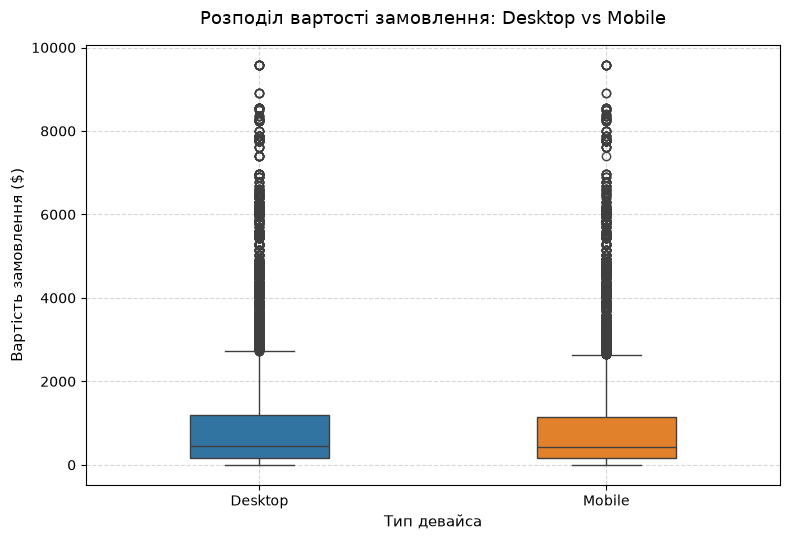

--- СЕРЕДНІ ЧЕКИ ТА МЕДІАНИ ---
Desktop: Середнє = 957.47 $, Медіана = 445.00 $
Mobile:  Середнє = 944.42 $, Медіана = 435.00 $

--- КРИТЕРІЙ МАННА-УЇТНІ ---
U-статистика: 130361108.5
p-value: 0.1586


In [ ]:
df_orders_dev = df[df['device_type'].isin(['desktop', 'mobile']) & df['price'].notnull()].copy()

desktop_orders = df_orders_dev[df_orders_dev['device_type'] == 'desktop']['price']
mobile_orders = df_orders_dev[df_orders_dev['device_type'] == 'mobile']['price']

mwu_dev_stat, p_val_dev_mwu = stats.mannwhitneyu(desktop_orders, mobile_orders, alternative='two-sided')

plt.figure(figsize=(8, 5.5))
sns.boxplot(
    data=df_orders_dev,
    x='device_type',
    y='price',
    hue='device_type',
    palette=['#1f77b4', '#ff7f0e'],
    legend=False,
    width=0.4
)

plt.xticks([0, 1], ['Desktop', 'Mobile'])
plt.title('Розподіл вартості замовлення: Desktop vs Mobile', fontsize=13, pad=15)
plt.xlabel('Тип девайса', fontsize=11)
plt.ylabel('Вартість замовлення ($)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("--- СЕРЕДНІ ЧЕКИ ТА МЕДІАНИ ---")
print(f"Desktop: Середнє = {desktop_orders.mean():,.2f} $, Медіана = {desktop_orders.median():,.2f} $")
print(f"Mobile:  Середнє = {mobile_orders.mean():,.2f} $, Медіана = {mobile_orders.median():,.2f} $\n")

print("--- КРИТЕРІЙ МАННА-УЇТНІ ---")
print(f"U-статистика: {mwu_dev_stat}")
print(f"p-value: {p_val_dev_mwu:.4f}")

In [ ]:
# ==========================================
# КРОК 8: Експорт очищеного датасету для Tableau Public
# ==========================================

In [ ]:
export_filename = 'portfolio_dataset_tableau.csv'

df.to_csv(export_filename, index=False)

print(f"--- ФАЙЛ УСПІШНО ЗБЕРЕЖЕНО ---")
print(f"Назва файлу: {export_filename}")
print(f"Кількість рядків: {len(df):,}")
print(f"Кількість колонок: {len(df.columns)}")
print(f"\nПерелік колонок для Tableau:\n{list(df.columns)}")

--- ФАЙЛ УСПІШНО ЗБЕРЕЖЕНО ---
Назва файлу: portfolio_dataset_tableau.csv
Кількість рядків: 349,545
Кількість колонок: 18

Перелік колонок для Tableau:
['session_date', 'ga_session_id', 'continent', 'country', 'device_type', 'browser', 'device_model', 'operating_system', 'browser_language', 'traffic_source', 'traffic_channel', 'user_id', 'is_email_confirmed', 'is_unsubscribed', 'product_category', 'product_name', 'price', 'product_description']
